# Deep Learning with TensorFlow — From Zero to Your First Neural Network

**Duration:** ~2 hours | **Level:** Absolute Beginner

---

## What are we building today?

A **Neural Network** that looks at a student's study hours and predicts
whether they will **Pass or Fail** — trained using TensorFlow/Keras.

No scary math. No complex theory. Just clear steps, lots of visuals,
and a working AI model by the end of this notebook.

---

## Our Journey Today

```
  PART 1  -> What IS Deep Learning? (plain English)
  PART 2  -> The building block: one neuron
  PART 3  -> Install & check TensorFlow
  PART 4  -> Create our dataset
  PART 5  -> Build the neural network (layer by layer)
  PART 6  -> Train the model
  PART 7  -> Visualise training progress
  PART 8  -> Make predictions
  PART 9  -> Evaluate the model
  PART 10 -> Challenges
```


---
## Part 1 - What IS Deep Learning?

### Machine Learning vs Deep Learning

You already know Machine Learning (linear regression, decision trees, etc.).
Deep Learning is a **subset** of Machine Learning that uses **Neural Networks**
with many layers.

```
        Artificial Intelligence
        +-------------------------------------------+
        |   Machine Learning                        |
        |   +-----------------------------------+   |
        |   |   Deep Learning                   |   |
        |   |   (Neural Networks)               |   |
        |   +-----------------------------------+   |
        +-------------------------------------------+
```

### Why is it called "Deep"?

Because the network has many **layers** stacked on top of each other.
Each layer learns something slightly more complex than the last.

```
  Input        Hidden        Hidden        Output
  Layer        Layer 1       Layer 2       Layer
  +------+     +------+     +------+     +------+
  |      |---> |      |---> |      |---> |      | --> Pass/Fail
  |      |     |      |     |      |     +------+
  |      |---> |      |---> |      |
  +------+     +------+     +------+

  Raw data   Simple       Complex      Final
  (4 values) patterns     patterns     prediction
```

### When should you use Deep Learning?

| Problem | Use |
|---------|-----|
| Recognising faces in photos | Deep Learning |
| Translating languages | Deep Learning |
| Predicting house prices (small tabular data) | Traditional ML (simpler!) |
| Playing video games | Deep Learning |
| Classifying emails as spam | Either works |

> **Key insight:** Deep Learning is NOT always better. For small tabular datasets
> like ours today, a Decision Tree may work just as well. But these same
> foundations power image recognition, ChatGPT, and self-driving cars.


---
## Part 2 - The Building Block: One Neuron

Before we build a network, let us understand **one neuron**.

### A biological neuron

```
  Dendrites           Cell Body       Axon
  (receive inputs) -> (process)  ->  (send output)
```

### An artificial neuron

```
  x1 -- w1 --+
  x2 -- w2 --+--> (sum + bias) --> activation(sum) --> output
  x3 -- w3 --+
```

**What each part does:**
- **Inputs (x)** - the data going in (e.g., study hours, attendance)
- **Weights (w)** - how important each input is (**learned during training!**)
- **Bias** - shifts the output (like the intercept in linear regression)
- **Activation function** - decides if the neuron "fires" or not

### The maths (just once!)

```
  output = activation( w1*x1 + w2*x2 + w3*x3 + bias )
```

That is it. A whole neural network is just thousands of these neurons
connected together. Let us visualise the two activation functions we will use today.


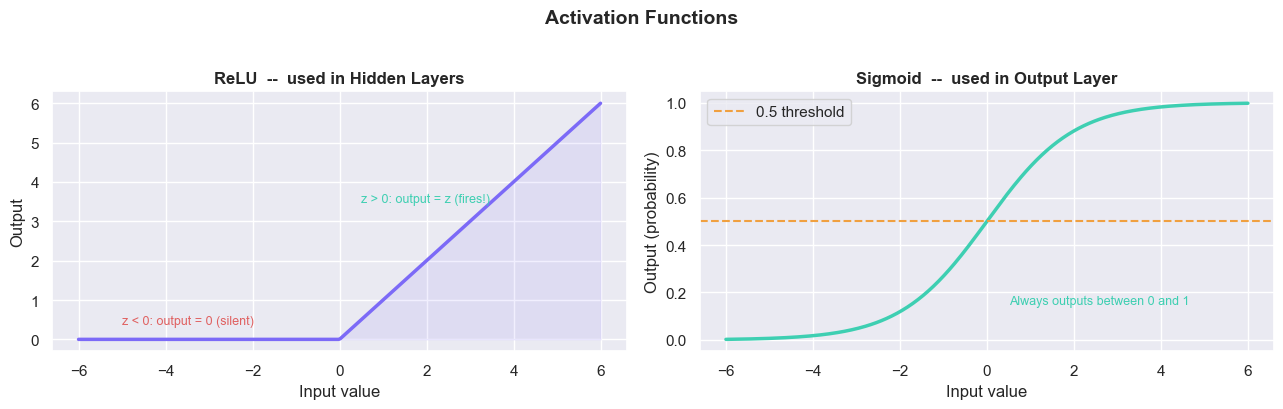

ReLU    -> Used in hidden layers. Simple and very effective.
Sigmoid -> Used in output layer for binary classification.
          Squashes output to [0,1] = probability!


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 4)
np.random.seed(42)

# Visualise activation functions
x = np.linspace(-6, 6, 300)
relu    = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ReLU
axes[0].plot(x, relu, color="#7c6af7", linewidth=2.5)
axes[0].fill_between(x, relu, alpha=0.1, color="#7c6af7")
axes[0].set_title("ReLU  --  used in Hidden Layers", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Input value"); axes[0].set_ylabel("Output")
axes[0].annotate("z < 0: output = 0 (silent)", xy=(-5, 0.4), color="#e06060", fontsize=9)
axes[0].annotate("z > 0: output = z (fires!)",  xy=(0.5, 3.5), color="#3ecfb2", fontsize=9)

# Sigmoid
axes[1].plot(x, sigmoid, color="#3ecfb2", linewidth=2.5)
axes[1].axhline(0.5, color="#f0a040", linewidth=1.5, linestyle="--", label="0.5 threshold")
axes[1].set_title("Sigmoid  --  used in Output Layer", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Input value"); axes[1].set_ylabel("Output (probability)")
axes[1].annotate("Always outputs between 0 and 1", xy=(0.5, 0.15), color="#3ecfb2", fontsize=9)
axes[1].legend()

plt.suptitle("Activation Functions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("ReLU    -> Used in hidden layers. Simple and very effective.")
print("Sigmoid -> Used in output layer for binary classification.")
print("          Squashes output to [0,1] = probability!")

---
## Part 3 - Install & Check TensorFlow


In [2]:
try:
    import tensorflow as tf
    print(f"TensorFlow version : {tf.__version__}")
    print(f"Keras version      : {tf.keras.__version__}")
except ImportError:
    print("Installing TensorFlow...")
    import subprocess
    subprocess.run(["pip", "install", "tensorflow", "--quiet"])
    import tensorflow as tf
    print(f"Installed TensorFlow {tf.__version__}")

TensorFlow version : 2.20.0
Keras version      : 3.12.0


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, accuracy_score)

tf.get_logger().setLevel('ERROR')

print("All imports ready!")
print()
print("Key TensorFlow concepts we will use:")
print("  Sequential  -> stack layers one after another")
print("  Dense       -> fully connected layer")
print("  model.fit() -> train the model (same as sklearn!)")

All imports ready!

Key TensorFlow concepts we will use:
  Sequential  -> stack layers one after another
  Dense       -> fully connected layer
  model.fit() -> train the model (same as sklearn!)


---
## Part 4 - Create Our Dataset

We will use a **student dataset** with 4 features to predict Pass or Fail.

| Feature | What it means |
|---------|--------------|
| `study_hours` | Hours studied per day |
| `attendance` | % of classes attended |
| `sleep_hours` | Hours of sleep per night |
| `prev_score` | Score in previous exam |
| `result` | **Target** - 1 = Pass, 0 = Fail |


In [4]:
np.random.seed(42)
n = 500

study_hours = np.round(np.random.uniform(1, 10, n), 1)
attendance  = np.random.randint(50, 101, n)
sleep_hours = np.round(np.random.uniform(4, 9, n), 1)
prev_score  = np.round(np.random.uniform(40, 100, n), 1)

score_combo = (0.4 * study_hours * 10 +
               0.3 * attendance  +
               0.1 * sleep_hours * 10 +
               0.2 * prev_score)
noise  = np.random.normal(0, 8, n)
result = (score_combo + noise >= 68).astype(int)

df = pd.DataFrame({
    "study_hours" : study_hours,
    "attendance"  : attendance,
    "sleep_hours" : sleep_hours,
    "prev_score"  : prev_score,
    "result"      : result
})

print(f"Dataset shape : {df.shape}")
print(f"Pass rate     : {result.mean()*100:.1f}%")
print(f"Fail rate     : {(1-result.mean())*100:.1f}%")
print()
df.head(8)

Dataset shape : (500, 5)
Pass rate     : 42.6%
Fail rate     : 57.4%



,study_hours,attendance,sleep_hours,prev_score,result
0,4.4,66,8.6,87.0,0
1,9.6,58,4.6,76.7,0
2,7.6,82,5.2,69.1,1
3,6.4,69,4.8,79.6,1
4,2.4,62,4.9,73.2,0
5,2.4,77,8.2,75.8,0
6,1.5,97,5.7,87.0,0
7,8.8,78,5.6,68.9,1


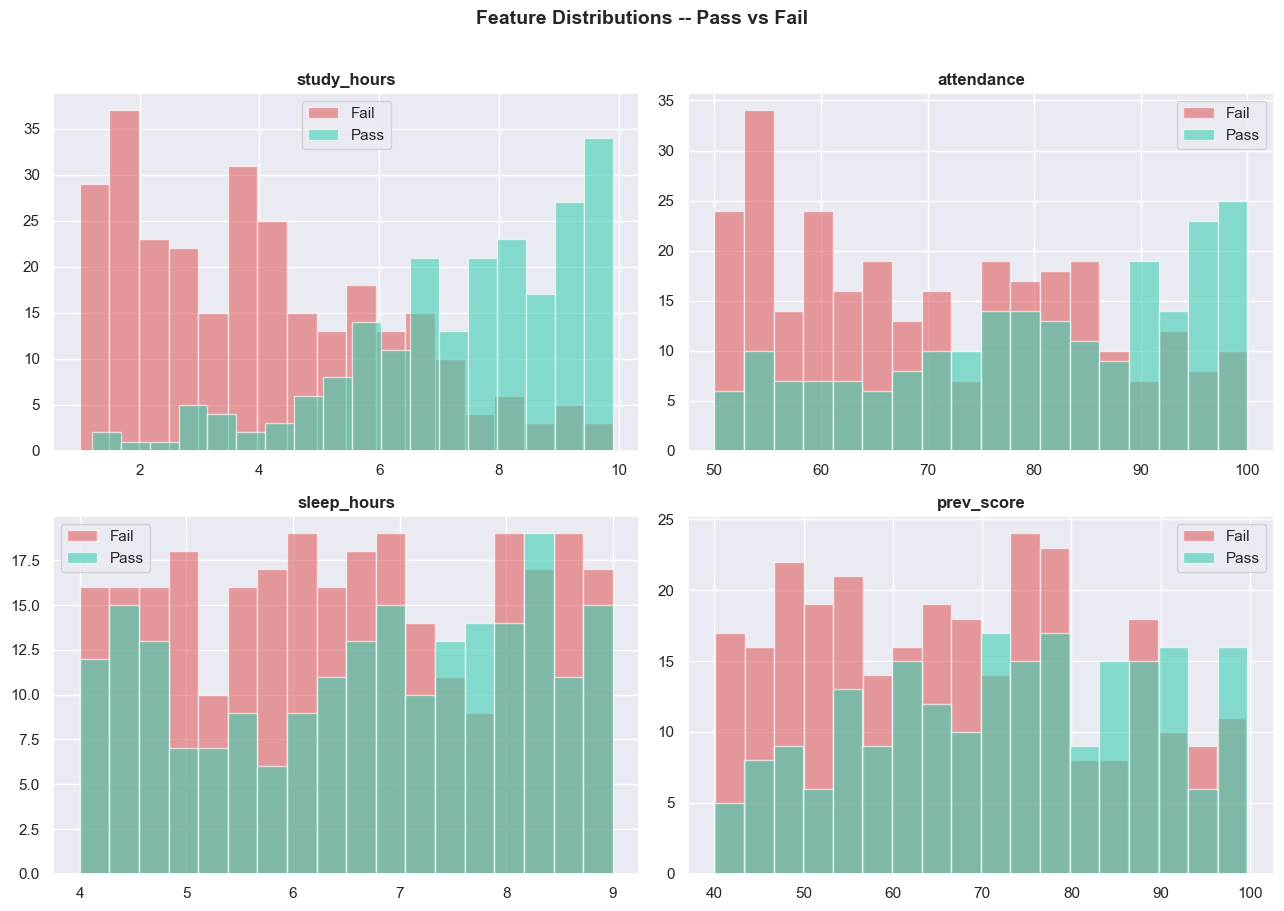

In [5]:
features = ["study_hours", "attendance", "sleep_hours", "prev_score"]
palette  = {1: "#3ecfb2", 0: "#e06060"}
label_map = {1: "Pass", 0: "Fail"}
df["label"] = df["result"].map(label_map)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flatten(), features):
    for val, grp in df.groupby("result"):
        ax.hist(grp[feat], bins=18, alpha=0.6,
                color=palette[val], edgecolor="white",
                label=label_map[val])
    ax.set_title(feat, fontweight="bold")
    ax.legend()

plt.suptitle("Feature Distributions -- Pass vs Fail",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Part 5 - Prepare Data for the Neural Network

Neural networks need three things:
1. **X and y** split (features and target)
2. **Train / test** split (just like all our previous models)
3. **Scaled features** (neural networks are very sensitive to scale!)


In [6]:
X = df[features].values
y = df["result"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

# Feature Scaling -- ALWAYS do this for neural networks
scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train)
X_test_s   = scaler.transform(X_test)

print()
print("Before scaling:")
print(f"  study_hours range : {X_train[:,0].min():.1f} to {X_train[:,0].max():.1f}")
print(f"  attendance range  : {X_train[:,1].min():.0f} to {X_train[:,1].max():.0f}")
print()
print("After scaling (all features: mean=0, std=1 -- same playing field!)")

Training samples : 400
Testing  samples : 100

Before scaling:
  study_hours range : 1.0 to 9.9
  attendance range  : 50 to 100

After scaling (all features: mean=0, std=1 -- same playing field!)


---
## Part 6 - Build the Neural Network

### Our Network Architecture

```
  INPUT          HIDDEN          HIDDEN          OUTPUT
  LAYER          LAYER 1         LAYER 2         LAYER
  (4 neurons)    (16 neurons)    (8 neurons)     (1 neuron)

  study_hours --+
  attendance  --+--> [16 neurons] --> [8 neurons] --> [1 neuron] --> Pass/Fail
  sleep_hours --+     (ReLU)           (ReLU)         (Sigmoid)
  prev_score  --+

  Raw data      Simple           Refined          Final
                patterns         patterns         probability
```

### Why these layer sizes?
- **16 neurons** in layer 1 -- gives the model room to find multiple patterns from 4 inputs
- **8 neurons** in layer 2 -- gradually compresses towards the final answer
- **1 neuron** output -- gives a single probability (Pass or Fail)

Think of it like a funnel: wide at the input, narrowing towards the answer.


In [7]:
tf.random.set_seed(42)

model = Sequential([
    # Hidden Layer 1 -- 16 neurons, ReLU activation
    # input_shape=(4,) tells Keras: each sample has 4 features
    Dense(16, activation='relu', input_shape=(4,), name="hidden_layer_1"),

    # Hidden Layer 2 -- 8 neurons, ReLU activation
    Dense(8, activation='relu', name="hidden_layer_2"),

    # Output Layer -- 1 neuron, Sigmoid activation
    # Sigmoid outputs a probability between 0 and 1
    Dense(1, activation='sigmoid', name="output_layer"),
])

print("Model built successfully!")
print()
model.summary()

Model built successfully!



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# What do these parameter counts mean?
print("Understanding the parameter count:")
print()
print("  hidden_layer_1 : 80 params")
print("    = (4 inputs x 16 neurons) + 16 biases")
print("    = 64 + 16 = 80")
print()
print("  hidden_layer_2 : 136 params")
print("    = (16 inputs x 8 neurons) + 8 biases")
print("    = 128 + 8 = 136")
print()
print("  output_layer   : 9 params")
print("    = (8 inputs x 1 neuron) + 1 bias")
print("    = 8 + 1 = 9")
print()
print("  TOTAL: 225 parameters -- all learned automatically during training!")

Understanding the parameter count:

  hidden_layer_1 : 80 params
    = (4 inputs x 16 neurons) + 16 biases
    = 64 + 16 = 80

  hidden_layer_2 : 136 params
    = (16 inputs x 8 neurons) + 8 biases
    = 128 + 8 = 136

  output_layer   : 9 params
    = (8 inputs x 1 neuron) + 1 bias
    = 8 + 1 = 9

  TOTAL: 225 parameters -- all learned automatically during training!


---
## Part 7 - Compile & Train the Model

### Before training, we must **compile** the model

| Setting | What we choose | Why |
|---------|---------------|-----|
| **Optimizer** | `adam` | Automatically adjusts learning rate -- best default |
| **Loss function** | `binary_crossentropy` | Standard for Pass/Fail problems |
| **Metrics** | `accuracy` | Easy to understand: % of correct predictions |

### What is an epoch?

One **epoch** = the model has seen every training sample once.

We train for multiple epochs so the model can refine its weights
again and again -- like a student revising notes multiple times.


In [9]:
model.compile(
    optimizer = 'adam',
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

print("Model compiled!")
print()
print("  optimizer='adam'           -> HOW the model updates its weights")
print("  loss='binary_crossentropy' -> WHAT the model tries to minimise")
print("  metrics=['accuracy']       -> WHAT we track to measure progress")

Model compiled!

  optimizer='adam'           -> HOW the model updates its weights
  loss='binary_crossentropy' -> WHAT the model tries to minimise
  metrics=['accuracy']       -> WHAT we track to measure progress


In [10]:
print("Training started...")
print()

history = model.fit(
    X_train_s, y_train,
    epochs           = 50,    # 50 passes through the training data
    batch_size       = 32,    # process 32 samples at a time
    validation_split = 0.2,   # hold back 20% of training data to monitor
    verbose          = 1      # show progress bar
)

print()
print("Training complete!")

Training started...

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6938 - loss: 0.6783 - val_accuracy: 0.7500 - val_loss: 0.6693
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7531 - loss: 0.6675 - val_accuracy: 0.7500 - val_loss: 0.6599
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7563 - loss: 0.6579 - val_accuracy: 0.7625 - val_loss: 0.6498
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7594 - loss: 0.6482 - val_accuracy: 0.7750 - val_loss: 0.6386
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7688 - loss: 0.6373 - val_accuracy: 0.7750 - val_loss: 0.6261
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7656 - loss: 0.6252 - val_accuracy: 0.7750 - val_loss: 0.6119
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7750 - loss: 0.6117 - val_accuracy: 0.7875 - val_loss: 0.5958
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7781 - loss: 0.5966 - val_ac

---
## Part 8 - Visualise Training Progress

The `history` object recorded loss and accuracy at every epoch.
This is the most important diagnostic chart in all of deep learning.

### How to read these charts

```
  HEALTHY TRAINING:
  - Both curves go DOWN (loss) or UP (accuracy)
  - Training and validation lines stay CLOSE together

  OVERFITTING:
  - Training keeps improving but validation plateaus or drops
  - A growing GAP between the two lines

  UNDERFITTING:
  - Both curves stop improving early
  - Accuracy is low for both lines
```


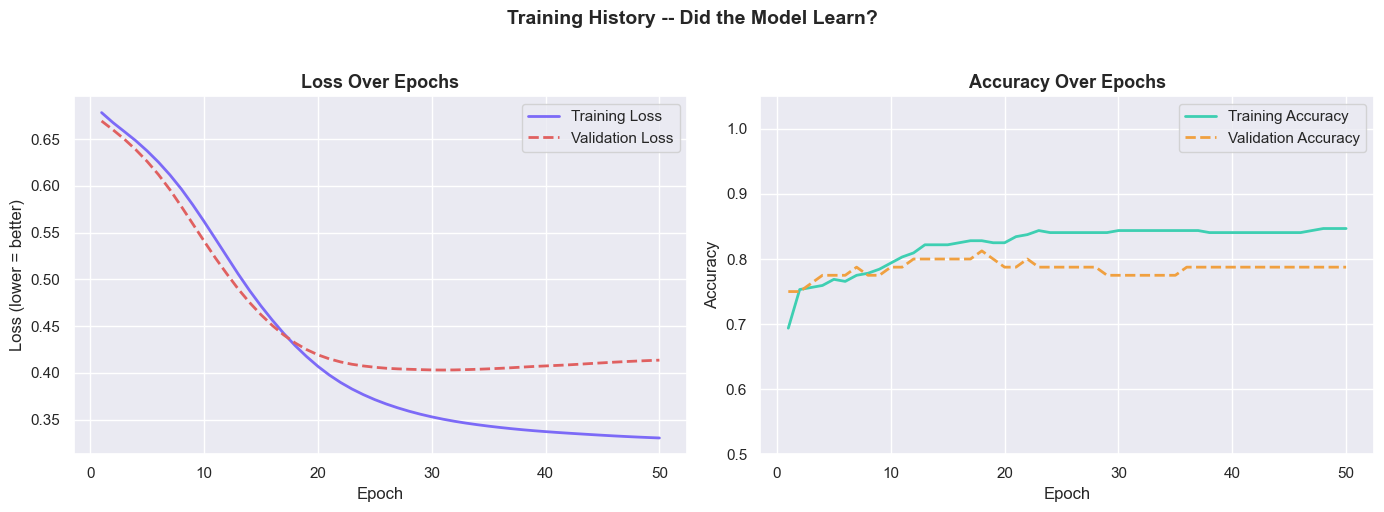

Final Training Accuracy   : 84.7%
Final Validation Accuracy : 78.8%

Gap is 5.9% -- watch for overfitting.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

# Loss curve
axes[0].plot(epochs_range, history.history['loss'],
             color="#7c6af7", linewidth=2, label="Training Loss")
axes[0].plot(epochs_range, history.history['val_loss'],
             color="#e06060", linewidth=2, linestyle="--", label="Validation Loss")
axes[0].set_title("Loss Over Epochs", fontweight="bold", fontsize=13)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (lower = better)")
axes[0].legend()

# Accuracy curve
axes[1].plot(epochs_range, history.history['accuracy'],
             color="#3ecfb2", linewidth=2, label="Training Accuracy")
axes[1].plot(epochs_range, history.history['val_accuracy'],
             color="#f0a040", linewidth=2, linestyle="--", label="Validation Accuracy")
axes[1].set_title("Accuracy Over Epochs", fontweight="bold", fontsize=13)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()

plt.suptitle("Training History -- Did the Model Learn?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

final_train = history.history['accuracy'][-1]
final_val   = history.history['val_accuracy'][-1]
print(f"Final Training Accuracy   : {final_train*100:.1f}%")
print(f"Final Validation Accuracy : {final_val*100:.1f}%")
print()
gap = abs(final_train - final_val)
if gap < 0.05:
    print("Gap between train/val is small -- healthy training!")
else:
    print(f"Gap is {gap*100:.1f}% -- watch for overfitting.")

---
## Part 9 - Make Predictions

`model.predict()` returns a **probability** for each student.
We then apply a threshold (0.5) to get Pass or Fail.


In [12]:
# Predict probabilities on test set
y_prob = model.predict(X_test_s, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Show first 10 predictions
sample = pd.DataFrame({
    "study_hrs"  : X_test[:10, 0],
    "attendance" : X_test[:10, 1].astype(int),
    "actual"     : ["Pass" if v==1 else "Fail" for v in y_test[:10]],
    "prob_pass"  : np.round(y_prob[:10], 3),
    "predicted"  : ["Pass" if v==1 else "Fail" for v in y_pred[:10]],
    "correct"    : y_test[:10] == y_pred[:10],
})
print("Sample predictions (first 10 test students):")
print()
print(sample.to_string(index=False))

Sample predictions (first 10 test students):

 study_hrs  attendance actual  prob_pass predicted  correct
       4.8          69   Pass      0.068      Fail    False
       6.5          99   Pass      0.871      Pass     True
       4.1          63   Fail      0.115      Fail     True
       2.9         100   Fail      0.410      Fail     True
       3.7          57   Fail      0.023      Fail     True
       7.8          86   Pass      0.910      Pass     True
       2.7          66   Fail      0.025      Fail     True
       1.4          60   Fail      0.006      Fail     True
       7.6          57   Pass      0.486      Fail    False
       6.6          93   Pass      0.922      Pass     True


In [13]:
# Predict for brand new students
print("=== Predict for New Students ===")
print()

new_students = pd.DataFrame({
    "name"        : ["Arjun",  "Priya",  "Ravi",  "Meera",  "Kiran"],
    "study_hours" : [7.5,       2.0,      5.0,     8.5,      3.5   ],
    "attendance"  : [90,        55,       75,      95,       60    ],
    "sleep_hours" : [7.0,       5.0,      6.5,     7.5,      4.5   ],
    "prev_score"  : [78,        45,       62,      88,       50    ],
})

new_scaled = scaler.transform(new_students[features])
new_prob   = model.predict(new_scaled, verbose=0).flatten()
new_pred   = (new_prob >= 0.5).astype(int)

print(f"{'Name':<8} {'Study':>6} {'Attend':>7} {'Prob':>8}  {'Result'}")
print("-" * 45)
for i, row in new_students.iterrows():
    result_str = "PASS" if new_pred[i] == 1 else "FAIL"
    bar = "#" * int(new_prob[i] * 20) + "." * (20 - int(new_prob[i] * 20))
    print(f"{row['name']:<8} {row['study_hours']:>6} "
          f"{row['attendance']:>7}  [{bar}] "
          f"{new_prob[i]:.0%}  {result_str}")

=== Predict for New Students ===

Name      Study  Attend     Prob  Result
---------------------------------------------
Arjun       7.5      90  [##################..] 92%  PASS
Priya       2.0      55  [....................] 0%  FAIL
Ravi        5.0      75  [###.................] 15%  FAIL
Meera       8.5      95  [###################.] 97%  PASS
Kiran       3.5      60  [....................] 1%  FAIL


---
## Part 10 - Evaluate the Model


In [14]:
test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.1f}%")
print()
print(classification_report(y_test, y_pred, target_names=["Fail","Pass"]))

Test Loss     : 0.3996
Test Accuracy : 83.0%

              precision    recall  f1-score   support

        Fail       0.86      0.84      0.85        57
        Pass       0.80      0.81      0.80        43

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



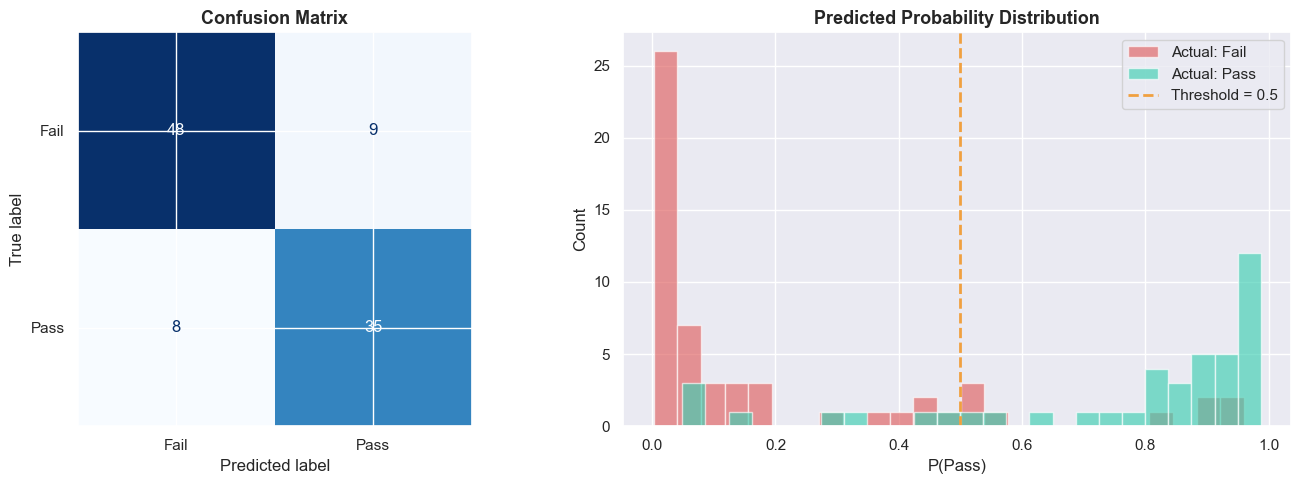

Correctly predicted PASS : 35
Correctly predicted FAIL : 48
Predicted Pass, actually Fail (Type I error)  : 9
Predicted Fail, actually Pass (Type II error) : 8


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail","Pass"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")

# Probability histogram
axes[1].hist(y_prob[y_test==0], bins=25, alpha=0.65,
             color="#e06060", edgecolor="white", label="Actual: Fail")
axes[1].hist(y_prob[y_test==1], bins=25, alpha=0.65,
             color="#3ecfb2", edgecolor="white", label="Actual: Pass")
axes[1].axvline(0.5, color="#f0a040", linewidth=2,
                linestyle="--", label="Threshold = 0.5")
axes[1].set_title("Predicted Probability Distribution",
                   fontsize=13, fontweight="bold")
axes[1].set_xlabel("P(Pass)"); axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Correctly predicted PASS : {tp}")
print(f"Correctly predicted FAIL : {tn}")
print(f"Predicted Pass, actually Fail (Type I error)  : {fp}")
print(f"Predicted Fail, actually Pass (Type II error) : {fn}")

---
## The Full Deep Learning Workflow

```
  Step 1 -> Prepare data     (split X/y, train/test, scale features)
  Step 2 -> Build model      (Sequential, Dense layers, activations)
  Step 3 -> Compile          (optimizer + loss + metrics)
  Step 4 -> Train            (model.fit with epochs)
  Step 5 -> Diagnose         (plot loss and accuracy curves)
  Step 6 -> Predict          (model.predict gives probabilities)
  Step 7 -> Evaluate         (confusion matrix, accuracy, report)
```

This exact workflow scales to:
- Image classification (add Conv2D layers)
- Text classification  (add Embedding + LSTM layers)
- Audio processing     (spectrogram + Conv layers)

The architecture changes. The workflow never does.


---
## Challenges - Make it Yours!


### Challenge 1 - Change the Epochs (Easy)

Re-train with `epochs=10` and then `epochs=100`.
- With 10 epochs: does the model have enough time to learn?
- With 100 epochs: does overfitting start to appear?

Plot and compare the training curves for all three (10, 50, 100).


In [16]:
# Challenge 1: Try epochs = 10 and epochs = 100
tf.random.set_seed(42)

model_10 = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid'),
])
model_10.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Uncomment and complete:
# history_10 = model_10.fit(X_train_s, y_train,
#                           epochs=10, batch_size=32,
#                           validation_split=0.2, verbose=0)
# print("10-epoch final val accuracy:",
#       round(history_10.history['val_accuracy'][-1]*100, 1), "%")

### Challenge 2 - Add a Third Hidden Layer (Easy)

Add one more Dense layer with **4 neurons** between the two existing
hidden layers and the output layer.

Does the extra depth improve or hurt test accuracy?


In [17]:
# Challenge 2: Deeper network
tf.random.set_seed(42)

deeper_model = Sequential([
    Dense(16, activation='relu', input_shape=(4,), name="layer_1"),
    Dense(8,  activation='relu',                   name="layer_2"),
    # ADD YOUR NEW LAYER HERE (hint: Dense(4, activation='relu'))
    Dense(1,  activation='sigmoid',                name="output"),
])

deeper_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
deeper_model.summary()

# history_deep = deeper_model.fit(X_train_s, y_train,
#                                 epochs=50, batch_size=32,
#                                 validation_split=0.2, verbose=0)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer_1 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

### Challenge 3 - Tune the Prediction Threshold (Medium)

The default threshold is 0.5. Try thresholds of 0.3, 0.4, 0.6, 0.7.

For each, print accuracy and how many students were incorrectly failed.

Which threshold would a school prefer if the goal is to
**catch struggling students early** and offer them support?


In [18]:
# Challenge 3: Threshold tuning
y_prob_test = model.predict(X_test_s, verbose=0).flatten()

print(f"{'Threshold':>10}  {'Accuracy':>10}  {'Missed fails (FN)':>20}")
print("-" * 45)
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (y_prob_test >= t).astype(int)
    acc   = accuracy_score(y_test, preds)
    cm_t  = confusion_matrix(y_test, preds)
    fn    = cm_t[1][0]
    print(f"{t:>10.1f}  {acc*100:>9.1f}%  {fn:>20}")

 Threshold    Accuracy     Missed fails (FN)
---------------------------------------------
       0.3       81.0%                     5
       0.4       81.0%                     6
       0.5       83.0%                     8
       0.6       85.0%                    10
       0.7       84.0%                    11


### Challenge 4 - Save & Load the Model (Medium)

Save the trained model to a file, load it back, and confirm it gives
identical predictions.

This is how real ML systems work -- train once, deploy everywhere.


In [19]:
# Challenge 4: Save and reload
model.save("student_model.keras")
print("Model saved!")

loaded_model = tf.keras.models.load_model("student_model.keras")
print("Model loaded!")

# Verify predictions match
orig   = model.predict(X_test_s[:5], verbose=0).flatten()
loaded = loaded_model.predict(X_test_s[:5], verbose=0).flatten()

print()
print("Original predictions:", np.round(orig,   4))
print("Loaded   predictions:", np.round(loaded, 4))
print("Identical?", np.allclose(orig, loaded))

Model saved!
Model loaded!

Original predictions: [0.0679 0.8714 0.1147 0.4099 0.0225]
Loaded   predictions: [0.0679 0.8714 0.1147 0.4099 0.0225]
Identical? True


---
## Wrap-Up

Today you built your **first neural network from scratch**:

- Understood what Deep Learning is and where it fits in AI
- Learned how a single neuron works (inputs x weights + bias -> activation)
- Understood ReLU and Sigmoid activation functions visually
- Built a Sequential model with Dense layers in TensorFlow/Keras
- Compiled with adam optimizer and binary_crossentropy loss
- Trained the model and read the training curves
- Made predictions with probability scores
- Evaluated with confusion matrix and classification report

---

### What comes next

```
  Today       -> Tabular data (numbers in a table)
  Next        -> Convolutional Neural Networks (CNNs) for IMAGES
  After that  -> Recurrent Neural Networks (RNNs) for TEXT/SEQUENCES
```

The architecture changes -- but the workflow
(build -> compile -> fit -> predict -> evaluate)
stays exactly the same forever.

You now know the foundation of all modern AI.
